# Тема 2. Визуальный анализ данных

## Практика: пассажиры «Титаника»

На теории глазами нашли, какие признаки телеком-клиентов различают ушедших и лояльных (box plot по классам, countplot с `hue`). Сейчас та же логика — на «Титанике»: какие признаки пассажиров различают выживших и погибших?

Самостоятельная работа. В отличие от практики по теме 1 — здесь нет вариантов ответа: результат визуальный, сверяйтесь с `lesson02_visual_practice_solution.ipynb`.

Если где-то не хватает метода из теории — загляните в `lesson02_visual_theory.ipynb`.

**Это файл с решениями — используйте его для самопроверки, а не вместо самостоятельной работы.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%config InlineBackend.figure_format = 'svg'

**Загрузим данные.** В `Cabin` очень много пропусков — уберём этот столбец, а затем удалим строки с оставшимися пропусками (это уберёт и пропуски в `Age`).

In [2]:
train_df = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
train_df = train_df.drop("Cabin", axis=1).dropna()
train_df.shape

(712, 10)

**1. Постройте матрицу диаграмм рассеяния (`pairplot`) для признаков `Age`, `Fare`, `SibSp`, `Parch` и `Survived`.**

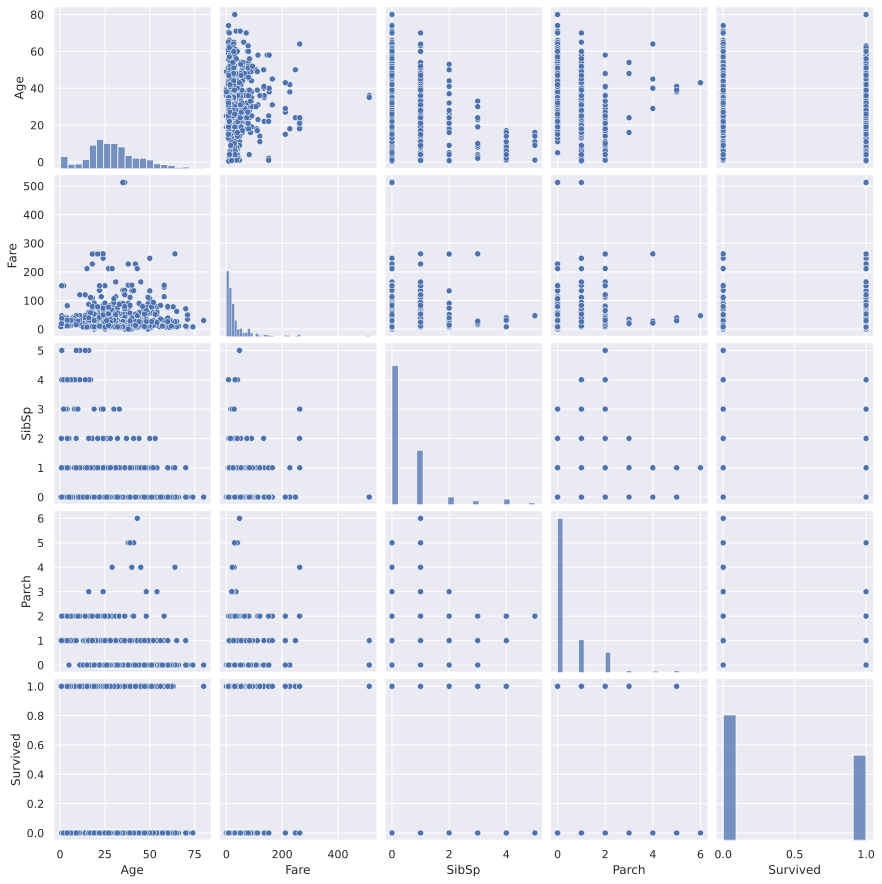

In [3]:
sns.pairplot(train_df[["Age", "Fare", "SibSp", "Parch", "Survived"]]);

**2. Как цена билета (`Fare`) зависит от класса каюты (`Pclass`)? Постройте boxplot.**

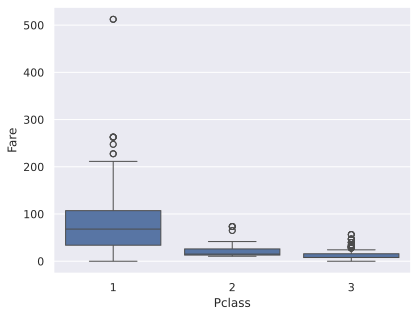

In [4]:
sns.boxplot(train_df, y="Fare", x="Pclass");

**3. Постройте тот же boxplot, но ограничьте `Fare` значениями ниже 95-го перцентиля (уберёт выбросы, график станет читаемее).**

*Подсказка:* `train_df["Fare"].quantile(0.95)`

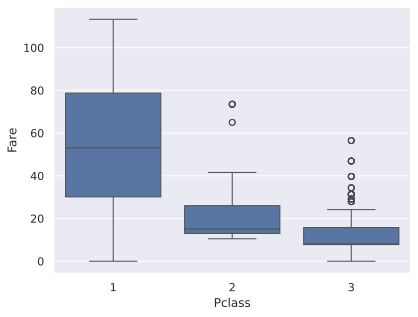

In [5]:
fare_q95 = train_df["Fare"].quantile(0.95)
sns.boxplot(train_df[train_df["Fare"] < fare_q95], y="Fare", x="Pclass");

**4. Как выживаемость зависит от пола пассажира? Используйте `countplot` с аргументом `hue="Survived"`.**

Дополнительно: посмотрите то же самое в разрезе `Pclass`.

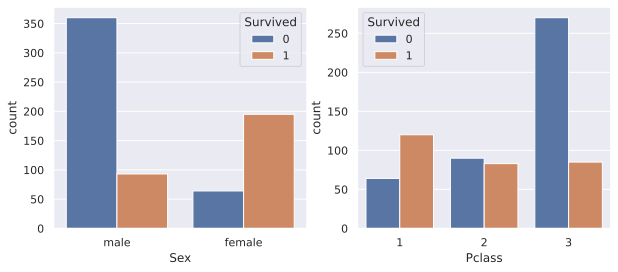

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Sex", hue="Survived", data=train_df, ax=axes[0])
sns.countplot(x="Pclass", hue="Survived", data=train_df, ax=axes[1]);

**5. Как распределялась цена билета (`Fare`) у выживших и у погибших? Постройте `boxplot`.**

Ограничьте `Fare < 500`, чтобы убрать экстремальные выбросы.

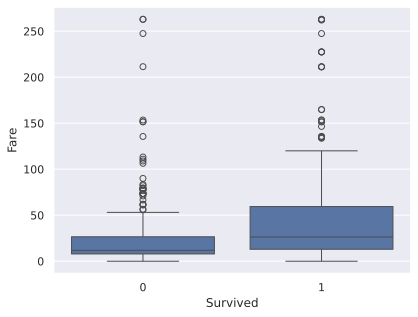

In [7]:
sns.boxplot(train_df[train_df["Fare"] < 500], x="Survived", y="Fare");

**6. Зависит ли выживаемость от возраста?**

Проверьте гипотезу: молодые пассажиры (< 30 лет) выживали чаще, чем пожилые (> 55 лет).

Создайте новый столбец `age_cat`:
- `1` — моложе 30
- `2` — от 30 до 55
- `3` — старше 55

Затем постройте `countplot` с `hue="Survived"` по этой переменной.

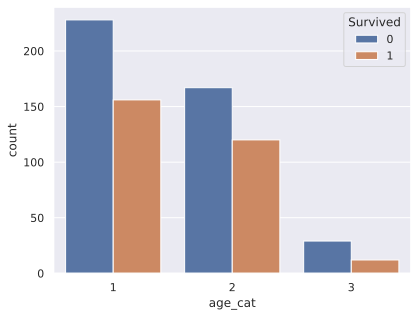

In [8]:
def age_cat(age):
    if age < 30:
        return 1
    elif age < 55:
        return 2
    else:
        return 3

train_df["age_cat"] = train_df["Age"].apply(age_cat)
sns.countplot(x="age_cat", hue="Survived", data=train_df);

---
## Итог

Следующее занятие — первые модели машинного обучения (деревья решений). Признаки, которые сегодня и на прошлом занятии выделялись визуально и через crosstab (`Customer service calls`, `International plan`, пол, класс каюты), там всплывут снова — уже как то, что модель находит автоматически.